In [1]:
# Importação das bibliotecas utilizadas na atividade

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv('data/heart.csv')

In [3]:
df.shape

(1025, 14)

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Informações de atributos do dataset

- **age** → idade da pessoa | Numérico Contínuo
- **sex** → sexo *(1 = homem, 0 = mulher)* | Categórico Binário
- **cp** → tipo de dor no peito *(4 categorias)* | Categórico Nominal
- **trestbps** → pressão arterial em repouso *(mmHg)* | Numérico Contínuo
- **chol** → nível de colesterol *(mg/dl)* | Numérico Contínuo
- **fbs** → glicemia alta em jejum *(1 = sim, 0 = não)* | Categórico Binário 
- **restecg** → resultado do eletrocardiograma *(0, 1, 2)* | Categórico Nominal
- **thalach** → frequência cardíaca máxima atingida | Numérico Contínuo
- **exang** → angina induzida por exercício *(1 = sim, 0 = não)* | Categórico Binário
- **oldpeak** → alteração cardíaca causada por esforço | Numérico Contínuo
- **slope** → inclinação dessa alteração durante exercício | Categórico Ordinal
- **ca** → número de vasos sanguíneos afetados *(0–3)* | Numérico Discreto
- **thal** → tipo de problema cardíaco *(0 = normal, 1 = fixo, 2 = reversível)* | Categórico Nominal

# Tratamento de Dados

In [6]:
# Identificar a quantidade de nulos por coluna

print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [7]:
# Identificar a quantidade de duplicatas por coluna

df.duplicated().sum()

np.int64(723)

In [8]:
df[df.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
15,34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
31,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
43,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
55,55,1,0,140,217,0,1,111,1,5.6,0,0,3,0
61,66,0,2,146,278,0,0,152,0,0.0,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


## 🚨🚨 IMPORTANTE 🚨🚨

Para fins educacionais, o criador do dataset original 'inflou' o conjunto de dados colocando elementos repetidos! De 1025 elementos no dataset, 723 são repetidos.
Portanto, devemos eliminar esses elementos duplicados

In [9]:
df_clean = df.drop_duplicates()
df_clean

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1,3,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2,0


# Visualização dos Dados

In [10]:
print("Informações Gerais do dataframe limpo")
df_clean.info()

Informações Gerais do dataframe limpo
<class 'pandas.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [11]:
print("Estatísticas Gerais do dataframe limpo")
df_clean.describe()

Estatísticas Gerais do dataframe limpo


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [12]:
print("Número de aparições do atributo 'target'")
print(df_clean['target'].value_counts())

print("============================================")

print("Porcentagem de aparições do atributo 'target'")
print(df_clean['target'].value_counts(normalize=True) * 100)

Número de aparições do atributo 'target'
target
1    164
0    138
Name: count, dtype: int64
Porcentagem de aparições do atributo 'target'
target
1    54.304636
0    45.695364
Name: proportion, dtype: float64


Distribuição de aparições do atributo 'target' no gráfico


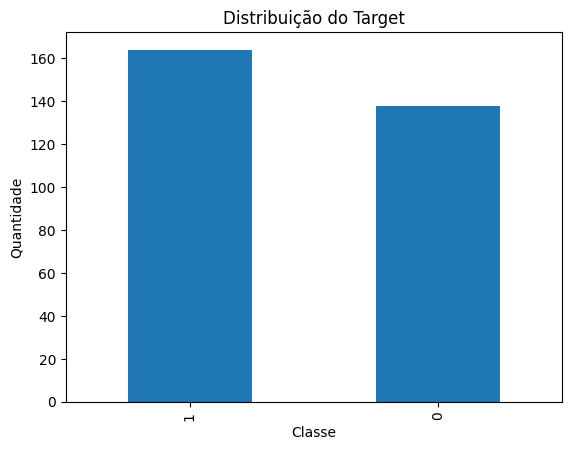

In [13]:
print("Distribuição de aparições do atributo 'target' no gráfico")
df_clean['target'].value_counts().plot(kind='bar')

plt.title("Distribuição do Target")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.show()

Detecção de Outliers


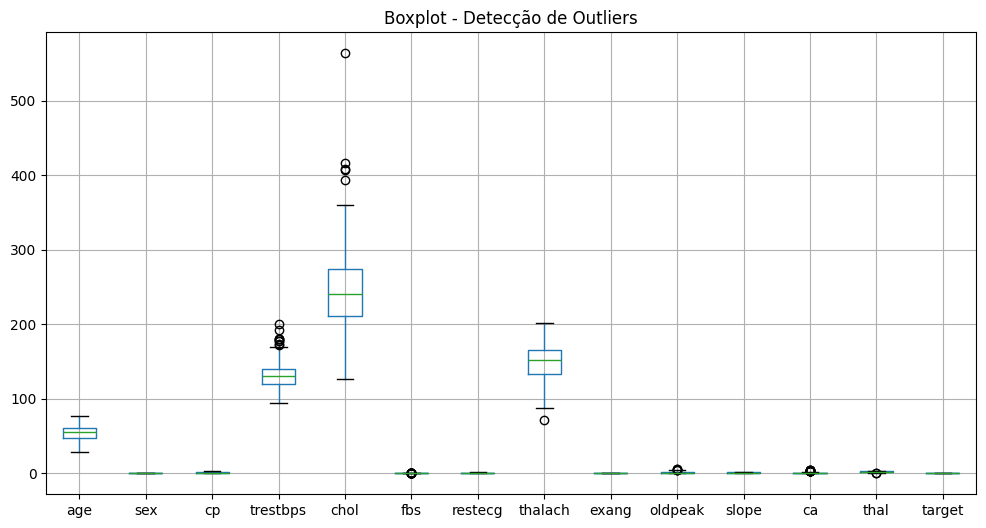

In [14]:
print("Detecção de Outliers")
df_clean.boxplot(figsize=(12,6))
plt.title("Boxplot - Detecção de Outliers")
plt.show()

In [15]:
Q1 = df_clean.quantile(0.25)
Q3 = df_clean.quantile(0.75)
IQR = Q3 - Q1

for col in df_clean.columns:
    outliers_col = df_clean[(df_clean[col] < (Q1[col] - 1.5 * IQR[col])) |
                            (df_clean[col] > (Q3[col] + 1.5 * IQR[col]))]
    
    print(f"{col}: {len(outliers_col)} outliers")

age: 0 outliers
sex: 0 outliers
cp: 0 outliers
trestbps: 9 outliers
chol: 5 outliers
fbs: 45 outliers
restecg: 0 outliers
thalach: 1 outliers
exang: 0 outliers
oldpeak: 5 outliers
slope: 0 outliers
ca: 24 outliers
thal: 2 outliers
target: 0 outliers


In [16]:
for col in df_clean.columns:
    outliers_col = df_clean[
        (df_clean[col] < (Q1[col] - 1.5 * IQR[col])) |
        (df_clean[col] > (Q3[col] + 1.5 * IQR[col]))
    ]
    
    if len(outliers_col) > 0:
        print(f"\n=== {col} ===")
        print(f"Quantidade de outliers: {len(outliers_col)}")
        print("Mínimo:", df_clean[col].min())
        print("Máximo:", df_clean[col].max())


=== trestbps ===
Quantidade de outliers: 9
Mínimo: 94
Máximo: 200

=== chol ===
Quantidade de outliers: 5
Mínimo: 126
Máximo: 564

=== fbs ===
Quantidade de outliers: 45
Mínimo: 0
Máximo: 1

=== thalach ===
Quantidade de outliers: 1
Mínimo: 71
Máximo: 202

=== oldpeak ===
Quantidade de outliers: 5
Mínimo: 0.0
Máximo: 6.2

=== ca ===
Quantidade de outliers: 24
Mínimo: 0
Máximo: 4

=== thal ===
Quantidade de outliers: 2
Mínimo: 0
Máximo: 3


# Pré-Processamento

In [17]:
# Aplicação da técnica One-Hot Enconding em atributos categóricos
df_process = df_clean.copy()

vars_categoricos = ['cp', 'restecg', 'thal']
df_process = pd.get_dummies(df_process, columns=vars_categoricos, drop_first=False)

In [18]:
# Identificação das colunas númericas do dataset
colunas_numericas = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

# Separando os dados
X = df_process.drop('target', axis=1)
y = df_process['target']

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Total: {len(X)}")
print(f"Treino: {len(X_treino)}")
print(f"Teste: {len(X_teste)}")


Total: 302
Treino: 241
Teste: 61


In [19]:
# Aplicando a normalização nas colunas númericas
X_treino = X_treino.copy()
X_teste = X_teste.copy()

scaler = MinMaxScaler()

X_treino[colunas_numericas] = scaler.fit_transform(X_treino[colunas_numericas])

X_teste[colunas_numericas] = scaler.transform(X_teste[colunas_numericas])

In [20]:
# Resultado esperado: X com várias colunas e y com apenas 1 coluna
print(X.shape)
print(y.shape)

(302, 21)
(302,)


In [21]:
# Checar se 'target' saiu de X
print('target' in X.columns)

False


In [22]:
# Dataset final! Normalizado e com o One-Hot Encoding
X_treino

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,...,cp_1,cp_2,cp_3,restecg_0,restecg_1,restecg_2,thal_0,thal_1,thal_2,thal_3
158,0.791667,0,0.214286,1.000000,0,0.679389,0,0.258065,1,0.00,...,False,True,False,True,False,False,False,False,False,True
199,0.437500,1,0.510204,0.168950,0,0.419847,1,0.145161,1,0.00,...,False,False,False,True,False,False,False,False,False,True
479,0.604167,1,0.346939,0.205479,0,0.458015,1,0.354839,1,0.75,...,False,False,False,True,False,False,False,False,False,True
460,0.833333,1,0.469388,0.292237,0,0.572519,0,0.322581,1,0.75,...,False,True,False,True,False,False,False,False,False,True
169,0.333333,0,0.183673,0.077626,0,0.511450,0,0.000000,1,0.00,...,True,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100,0.291667,0,0.285714,0.198630,0,0.717557,0,0.032258,1,0.00,...,False,True,False,False,True,False,False,False,True,False
320,0.500000,0,0.367347,0.315068,0,0.549618,0,0.064516,1,0.00,...,False,False,False,True,False,False,False,False,True,False
472,0.604167,0,0.367347,0.162100,0,0.458015,0,0.096774,1,0.00,...,False,False,False,False,True,False,False,False,True,False
733,0.312500,0,0.142857,0.034247,0,0.793893,0,0.096774,1,0.00,...,False,True,False,False,True,False,False,False,True,False


# Implementação e Experimentação

In [23]:
k_valores = range(1,16)
metricas = {
    "euclidean": [],
    "manhattan": [],
    "chebyshev": [],
    "minkowski_p3": []
}

for k in k_valores:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_treino, y_treino)
    metricas['euclidean'].append(accuracy_score(y_teste, knn.predict(X_teste)))

    knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    knn.fit(X_treino, y_treino)
    metricas['manhattan'].append(accuracy_score(y_teste, knn.predict(X_teste)))

    knn = KNeighborsClassifier(n_neighbors=k, metric='chebyshev')
    knn.fit(X_treino, y_treino)
    metricas['chebyshev'].append(accuracy_score(y_teste, knn.predict(X_teste)))

    knn = KNeighborsClassifier(n_neighbors=k, metric="minkowski", p=3)
    knn.fit(X_treino, y_treino)
    metricas['minkowski_p3'].append(accuracy_score(y_teste, knn.predict(X_teste)))

(0.5, 1.0)

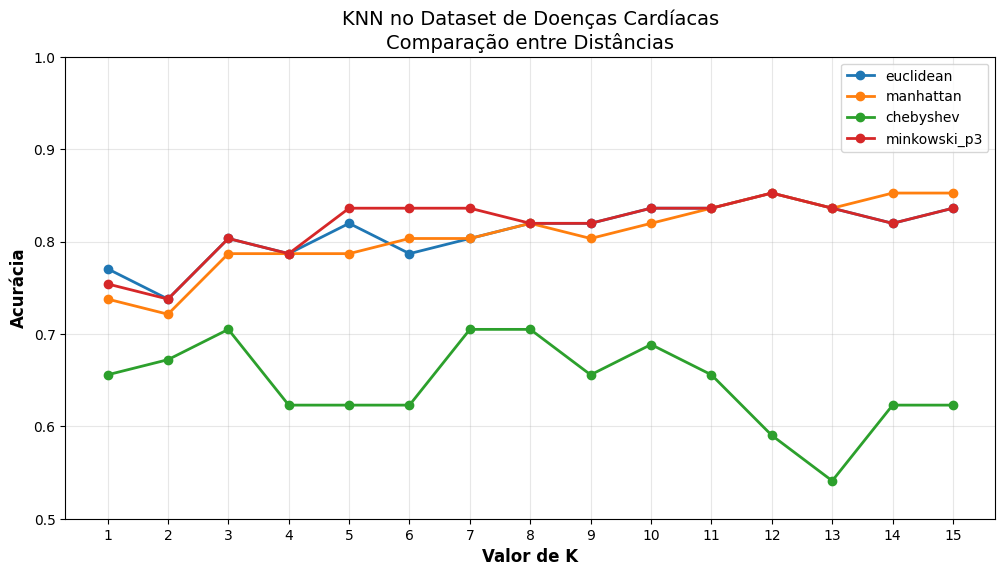

In [24]:
plt.figure(figsize=(12, 6))
for distancia, acuracias in metricas.items():
    plt.plot(k_valores, acuracias, marker='o', linewidth=2, label=distancia)
    
plt.xlabel('Valor de K', fontsize=12, fontweight='bold')
plt.ylabel('Acurácia', fontsize=12, fontweight='bold')
plt.title('KNN no Dataset de Doenças Cardíacas\nComparação entre Distâncias', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.xticks(k_valores)
plt.ylim(0.5, 1.0)

In [28]:
df_resultados = pd.DataFrame(metricas, index=k_valores)

display(df_resultados * 100)

,euclidean,manhattan,chebyshev,minkowski_p3
1,77.049180,73.770492,65.573770,75.409836
2,73.770492,72.131148,67.213115,73.770492
3,80.327869,78.688525,70.491803,80.327869
4,78.688525,78.688525,62.295082,78.688525
5,81.967213,78.688525,62.295082,83.606557
6,78.688525,80.327869,62.295082,83.606557
7,80.327869,80.327869,70.491803,83.606557
8,81.967213,81.967213,70.491803,81.967213
9,81.967213,80.327869,65.573770,81.967213
10,83.606557,81.967213,68.852459,83.606557
